## Import Libraries

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

## Read DataSet

In [48]:
df = pd.read_csv("Titanic.csv")

## Data Overview

In [49]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [50]:
df.shape

(891, 12)

In [51]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [52]:
def data_overview(data):
    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Duplicates':duplicates})
    return info_df

In [53]:
data_overview(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Duplicates
0,PassengerId,int64,"[1, 599, 588, 589, 590, 591, 592, 593, 594, 595]",891,0,0
1,Survived,int64,"[0, 1]",2,0,0
2,Pclass,int64,"[3, 1, 2]",3,0,0
3,Name,object,"[Braund, Mr. Owen Harris, Boulos, Mr. Hanna, F...",891,0,0
4,Sex,object,"[male, female]",2,0,0
5,Age,float64,"[24.0, 22.0, 18.0, 19.0, 28.0, 30.0, 21.0, 25....",88,177,0
6,SibSp,int64,"[0, 1, 2, 4, 3, 8, 5]",7,0,0
7,Parch,int64,"[0, 1, 2, 5, 3, 4, 6]",7,0,0
8,Ticket,object,"[347082, CA. 2343, 1601, 3101295, CA 2144, 347...",681,0,0
9,Fare,float64,"[8.05, 13.0, 7.8958, 7.75, 26.0, 10.5, 7.925, ...",248,0,0


In [54]:
df.isna().sum().sum()

np.int64(866)

# **Insights**

- **Rows:** 891
- **Columns:** 12
- **Missing Values:** 866
- **Target Variable:** `Survived` (`0 = Did Not Survive`, `1 = Survived`)

**Insights**
- The dataset contains **891 passengers** described by **12 features**.
- A total of **866 missing values** are present, mainly in the **Cabin**, **Age**, and **Embarked** columns.
- Since this is a binary classification problem, the **Survived** column will be used as the target variable.

---

## Data Types

| Data Type | Columns |
|-----------|---------|
| **Integer (5)** | `PassengerId`, `Survived`, `Pclass`, `SibSp`, `Parch` |
| **Float (2)** | `Age`, `Fare` |
| **Object (5)** | `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked` |

**Insights**
- The dataset contains a mix of **numerical** and **categorical** features.
- Numerical features include passenger demographics and family information.
- Categorical features describe passenger identity, gender, ticket details, cabin assignment, and embarkation port.

---

## Initial Observations

### PassengerId
- `PassengerId` is a unique identifier assigned to each passenger.
- Since every value is unique, it is unlikely to contribute meaningful information for prediction.

### Age
- Passenger ages range from **0.42** to **80** years.
- Although some ages appear much larger than the upper quartile, they represent valid observations rather than erroneous outliers.

### Fare
- The maximum fare is **512.329**, whereas the 75th percentile is only **31**.
- This indicates a **right-skewed distribution** with several high-fare outliers that may require further analysis during preprocessing.

### Cabin
- The `Cabin` feature contains a substantial number of missing values, making it the least complete feature in the dataset.

### Ticket
- The `Ticket` column has many unique values, which may reduce its usefulness as a predictive feature without feature engineering.

### Cabin
- The `Cabin` column has high cardinality and contains a very large percentage of missing values.

---

## Target Variable Analysis

| Class | Percentage |
|-------|-----------:|
| **Did Not Survive (0)** | **61.7%** |
| **Survived (1)** | **38.3%** |

**Insights**
- Most passengers did **not survive** the disaster.
- The target classes are **moderately imbalanced**, but the imbalance is not severe enough to prevent training classification models.

# Make Visualizations to get Information about the data

## Survived (Target) Distribution 

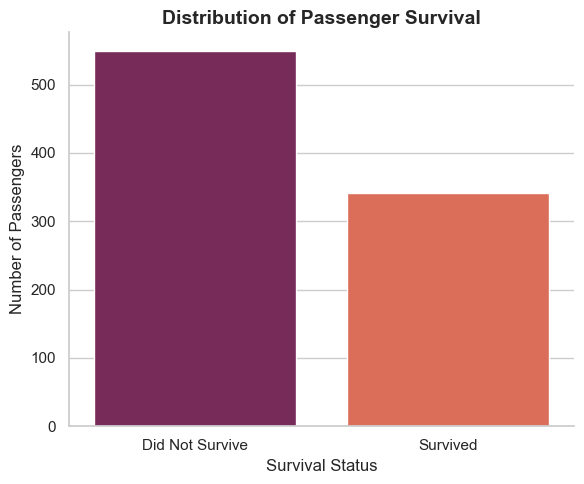

In [55]:
sns.set_theme(style="whitegrid")

counts = df["Survived"].value_counts().sort_index()

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=["Did Not Survive", "Survived"],
    y=counts.values,
    hue=["Did Not Survive", "Survived"],
    palette="rocket",
    legend=False
)


plt.title("Distribution of Passenger Survival", fontsize=14, fontweight="bold")
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

Most Passengers did not survive 

## Pclass

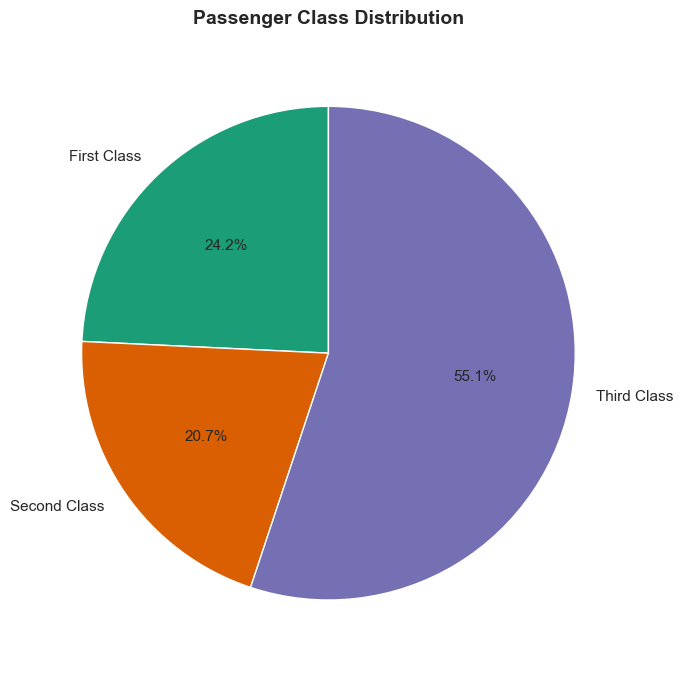

In [56]:
import matplotlib.pyplot as plt

Pclass_counts = df["Pclass"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    Pclass_counts.values,
    labels=["First Class", "Second Class", "Third Class"],
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Dark2.colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11}
)

plt.title("Passenger Class Distribution", fontsize=14, fontweight="bold")

plt.axis("equal") 
plt.tight_layout()
plt.show()

- More than half of the passengers (**55.1%**) traveled in **Third Class**.
- **First Class** accounted for approximately **24.2%** of passengers, while **Second Class** represented **20.7%**.
- The dataset contains a noticeably larger proportion of Third Class passengers.

## Sex vs Survived 

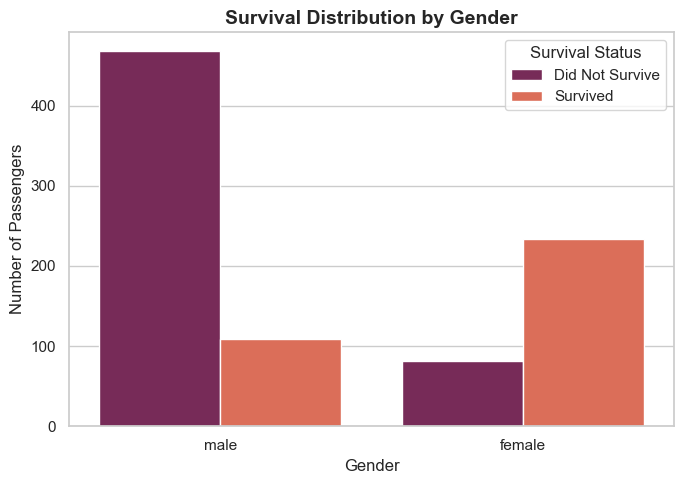

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived",
    palette="rocket"
)

plt.title("Survival Distribution by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

plt.tight_layout()
plt.show()

* Huge number of male passengers did not survived compared to the female passengers

## Pclass vs Survived

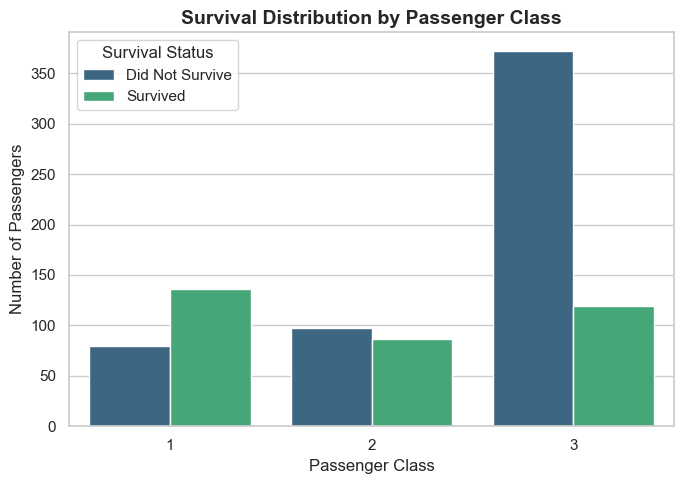

In [58]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived",
    palette="viridis"
)

plt.title("Survival Distribution by Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

plt.tight_layout()
plt.show()

* First-class passengers had a higher survival proportion.
* Third-class passengers had the highest number of deaths.

## Embarked vs Survival

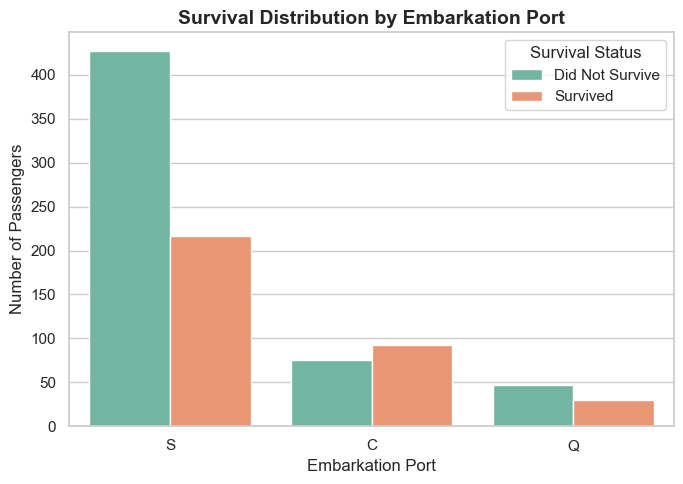

In [59]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived",
    palette="Set2"
)

plt.title("Survival Distribution by Embarkation Port", fontsize=14, fontweight="bold")
plt.xlabel("Embarkation Port", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.legend(
    title="Survival Status",
    labels=["Did Not Survive", "Survived"]
)

plt.tight_layout()
plt.show()

* Passengers who embarked from different ports showed different survival distributions.
* The variation may be related to passenger class distribution across ports.

## Pclass VS Embarked

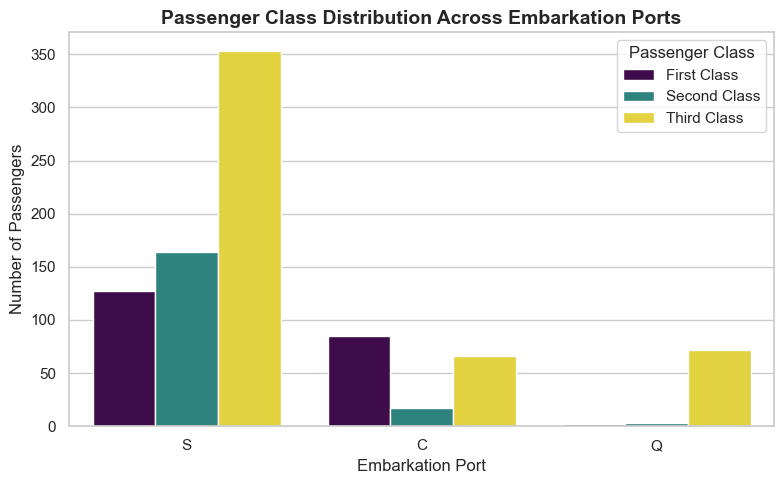

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df,x="Embarked",hue="Pclass",palette="viridis")

plt.title("Passenger Class Distribution Across Embarkation Ports", fontsize=14, fontweight="bold")

plt.xlabel("Embarkation Port", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)

plt.legend(title="Passenger Class",labels=["First Class", "Second Class", "Third Class"])

plt.tight_layout()
plt.show()

- Passengers who embarked from **Southampton (S)** represent the majority of the dataset and contain the largest number of Third Class passengers.
- **Cherbourg (C)** has a relatively higher proportion of First Class passengers compared to the other ports.

## Fare vs Survival

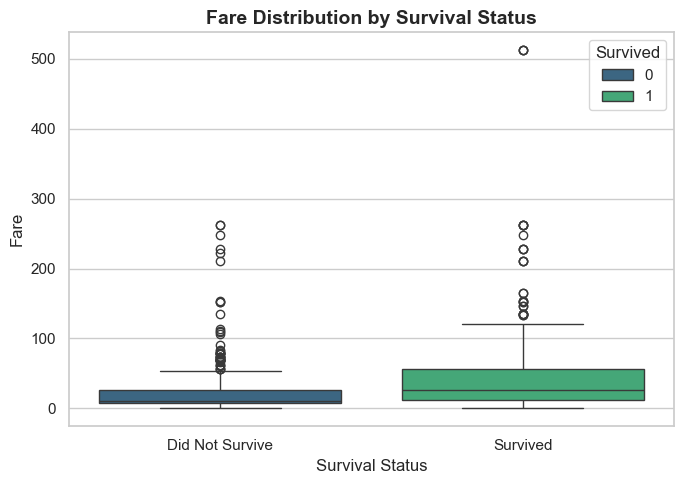

In [61]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare",
    palette="viridis" ,
    hue = "Survived"
)

plt.title("Fare Distribution by Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Fare", fontsize=12)

plt.xticks(
    [0,1],
    ["Did Not Survive", "Survived"]
)

plt.tight_layout()
plt.show()

* Survivors generally paid higher fares compared to non-survivors.
* Higher fares may indicate higher passenger class and better access to lifeboats.

## Distribution of Age

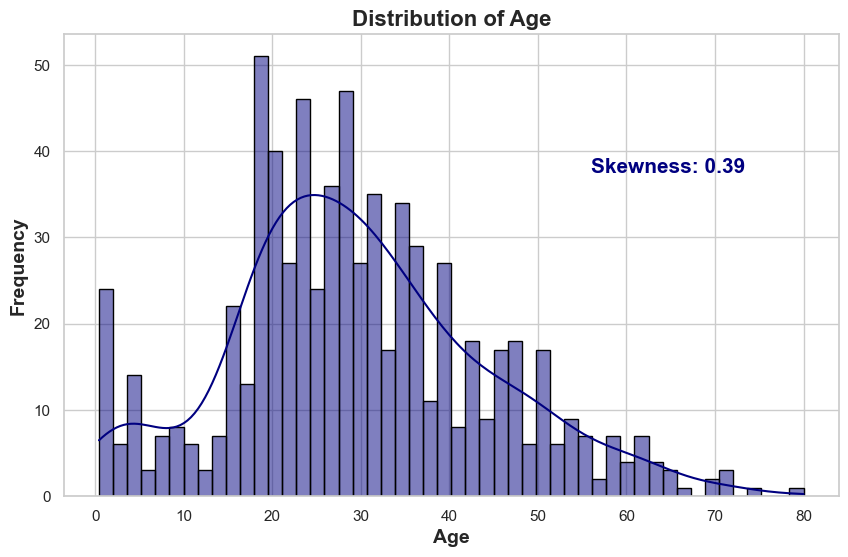

In [62]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

skewness = skew(df['Age'], nan_policy="omit")
sns.histplot(df['Age'], bins=50, kde=True, color="navy", edgecolor="black")

plt.xlabel('Age', fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.title(f"Distribution of Age", fontsize=16, fontweight='bold')

plt.text(
    x=df['Age'].max() * 0.7,
    y=plt.gca().get_ylim()[1] * 0.7,
    s=f"Skewness: {skewness:.2f}",
    fontsize=15, fontweight="bold", color="navy"
)

plt.show()

## Age vs Survived

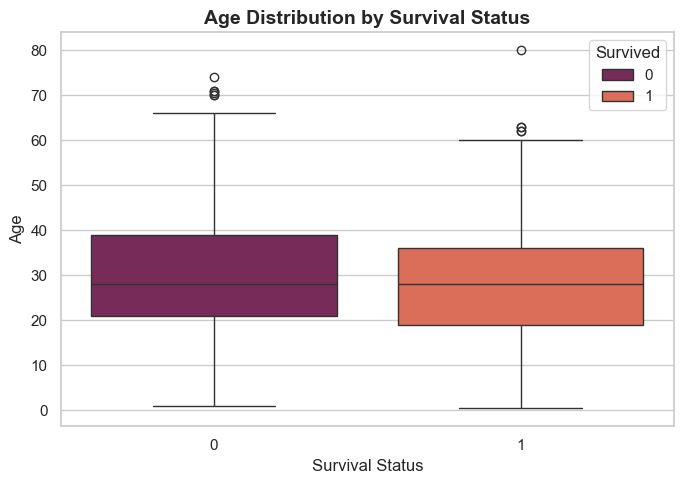

In [63]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age",
    palette="rocket",
    hue = 'Survived'
)

plt.title("Age Distribution by Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Survival Status", fontsize=12)
plt.ylabel("Age", fontsize=12)

plt.xticks(
    [0,1],
)

plt.tight_layout()
plt.show()

* The age distributions of survivors and non-survivors are relatively similar.
* Age alone may not be a strong predictor, but it could provide useful information combined with other features.


## Distribution Shape

- The `Age` column shows a **slightly right-skewed distribution** with a positive skewness value (**0.39**).
- Most passengers are young adults, with the highest concentration of passengers between **20 and 30 years old**.
- The distribution includes younger passengers (including infants) as well as older passengers, with the maximum age reaching **80 years**.
- The presence of older passengers creates a longer tail toward higher age values, resulting in positive skewness.

## Outliers Analysis

- Although some passengers have ages significantly higher than the median age, these values represent **valid observations** rather than data entry errors.
- Age is a natural demographic feature, so these extreme values do not require removal.
- The age distribution will be analyzed further during preprocessing to determine whether any transformation is beneficial for the model.

## Passenger Class vs Fare

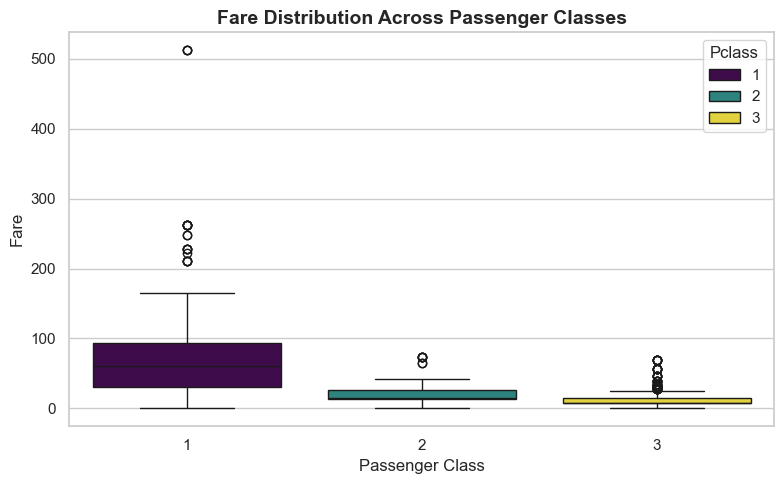

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    palette="viridis",  hue="Pclass"
)

plt.title("Fare Distribution Across Passenger Classes", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Fare", fontsize=12)

plt.tight_layout()
plt.show()

- First-class passengers generally paid significantly higher fares compared to second and third-class passengers.
- This confirms that `Pclass` and `Fare` are strongly related features.
- The presence of high fares in First Class explains the right-skewed distribution of the `Fare` column.

# **Make Preprocessing (Nulls, Duplicates, Outliers)**

The following features were excluded from the initial modeling process:

- **PassengerId:**  
  This column serves only as a unique identifier for each passenger and does not contain meaningful predictive information. Therefore, it was removed to prevent the model from learning irrelevant patterns.

- **Cabin:**  
  The `Cabin` feature contains a very high percentage of missing values (more than 70%), making it difficult to use effectively in its original form. It was excluded from the initial model training.

- **Ticket:**  
  The `Ticket` column contains high-cardinality values with many unique ticket numbers. Using it directly may introduce noise and increase model complexity, so it was removed from the initial feature set.

- **Name:**  
  The `Name` feature contains individual passenger names, which behave similarly to unique identifiers. Since the raw values do not provide direct predictive information, it was excluded from the initial modeling process.


In [65]:
df = df.drop([ 'PassengerId' , 'Ticket' ], axis=1)

* After dropping the selected columns, the `data_overview()` function was executed again to review the updated dataset.
* The purpose of this step is to verify the dataset structure and check for any duplicate records before continuing with further preprocessing.

data_overview(df)

## **Duplicates**

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df.duplicated().sum()

np.int64(0)

## **Handling Null Values**


In [69]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [70]:
df['Embarked'] = df['Embarked'].fillna( df['Embarked'].mode()[0] )
df['Embarked'].isnull().sum()

np.int64(0)

In [71]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

## **Handling Outliers**


In [72]:
outlier_columns = ['Age' , 'Fare']

In [73]:
df['Age'] = df['Age'].astype(int)

In [74]:
for col in outlier_columns:

    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower_bound=Q1-(1.5*IQR)
    upper_bound=Q3+(1.5*IQR)

    outliers_mask_lower_before_handling = (df[col] < lower_bound)
    outliers_mask_upper_before_handling = (df[col] > upper_bound)

    outliers_count_lower_before_handling = outliers_mask_lower_before_handling.sum()
    outliers_count_upper_before_handling = outliers_mask_upper_before_handling.sum()

    print(f"Number of lower Outliers in {col} (Before) : {outliers_count_lower_before_handling}")
    print(f"Number of upper Outliers in {col} (Before) : {outliers_count_upper_before_handling}")

    df[col]=np.where(df[col]<lower_bound,lower_bound,df[col])
    df[col]=np.where(df[col]>upper_bound,upper_bound,df[col])

    outliers_mask_lower_after_handling = (df[col] < lower_bound)
    outliers_mask_upper_after_handling = (df[col] > upper_bound)

    outliers_count_lower_after_handling = outliers_mask_lower_after_handling.sum()
    outliers_count_upper_after_handling = outliers_mask_upper_after_handling.sum()

    print(f"Number of lower Outliers in {col} (After): {outliers_count_lower_after_handling}")
    print(f"Number of upper Outliers in {col} (After): {outliers_count_upper_after_handling}" , end = '\n\n')

Number of lower Outliers in Age (Before) : 24
Number of upper Outliers in Age (Before) : 42
Number of lower Outliers in Age (After): 0
Number of upper Outliers in Age (After): 0

Number of lower Outliers in Fare (Before) : 0
Number of upper Outliers in Fare (Before) : 116
Number of lower Outliers in Fare (After): 0
Number of upper Outliers in Fare (After): 0



## **Feature Engineering**

In [75]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = np.where(df["FamilySize"] == 1,1,0)
df["FamilySize_Category"] = pd.cut(df["FamilySize"],bins=[0, 1, 4, 7, 20],labels=["Alone", "Small", "Medium", "Large"])
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.",expand=False)
rare_titles = ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"]
df["Title"] = df["Title"].replace(rare_titles,"Rare")
df["Title"] = df["Title"].replace(["Mlle", "Ms"],"Miss")
df["Title"] = df["Title"].replace("Mme","Mrs")
df["Deck"] = df["Cabin"].str[0]
df["Deck"] = df["Deck"].fillna("Unknown")
df["Fare"] = np.log1p(df["Fare"])
df = df.drop(["Name","Cabin","SibSp","Parch"],axis=1)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,FamilySize_Category,Title,Deck
0,0,3,male,22.0,2.110213,S,2,0,Small,Mr,Unknown
1,1,1,female,38.0,4.199221,C,2,0,Small,Mrs,C
2,1,3,female,26.0,2.188856,S,1,1,Alone,Miss,Unknown
3,1,1,female,35.0,3.990834,S,2,0,Small,Mrs,C
4,0,3,male,35.0,2.202765,S,1,1,Alone,Mr,Unknown


# **Split Data**

In [76]:
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Encoding**

In [77]:
categorical_columns = X_train.select_dtypes(include=["object", "category"]).columns
X_train = pd.get_dummies(X_train,columns=categorical_columns,drop_first=True)

X_test = pd.get_dummies(X_test,columns=categorical_columns,drop_first=True)
X_train, X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)
X_train = X_train.astype(int)

X_test = X_test.astype(int)

# **Scaling**

In [78]:
scale_columns = ["Age","Fare","FamilySize"]
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

# **Correlation**

### ANOVA Test (Numerical Features)

In [79]:
numerical_features = [
    "Age",
    "Fare",
    "FamilySize"
]


X_anova = df[numerical_features]
y_anova = df["Survived"]


f_scores, p_values = f_classif(
    X_anova,
    y_anova
)


anova_results = pd.DataFrame({

    "Feature": numerical_features,
    "F-Score": f_scores,
    "P-Value": p_values

})


anova_results = anova_results.sort_values(
    by="F-Score",
    ascending=False
)


anova_results

,Feature,F-Score,P-Value
1,Fare,102.767561,6.282863e-23
0,Age,3.227014,7.277204e-02
2,FamilySize,0.246193,6.198911e-01


### Chi-Square Test (Categorical Features)

In [80]:
categorical_features = ["Sex","Embarked","Pclass","Title","Deck"]

chi_df = df[categorical_features].copy()
chi_df = pd.get_dummies(chi_df,drop_first=True)
chi_scores, chi_pvalues = chi2(chi_df,df["Survived"])
chi_results = pd.DataFrame({"Feature": chi_df.columns,"Chi2 Score": chi_scores,"P-Value": chi_pvalues})
chi_results = chi_results.sort_values(by="Chi2 Score",ascending=False)


chi_results

,Feature,Chi2 Score,P-Value
5,Title_Mr,112.805785,2.379805e-26
1,Sex_male,92.702447,6.077838e-22
6,Title_Mrs,89.474177,3.106671e-21
4,Title_Miss,79.531749,4.745381e-19
0,Pclass,30.873699,2.753786e-08
8,Deck_B,25.875581,3.641468e-07
15,Deck_Unknown,20.488314,5.999642e-06
10,Deck_D,19.489646,1.011464e-05
11,Deck_E,18.140638,2.051756e-05
9,Deck_C,10.936730,9.427644e-04


# **Balance the Data**

In [81]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# **Evaluation the Model**

In [82]:

models = {

    "Logistic Regression": LogisticRegression(max_iter=2000,C=1,random_state=42),

    "Decision Tree": DecisionTreeClassifier(max_depth=5,min_samples_split=5,min_samples_leaf=3,random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=300,max_depth=7,min_samples_split=5,min_samples_leaf=2,max_features="sqrt",random_state=42),

    "KNN": KNeighborsClassifier(n_neighbors=14),

    "SVM": SVC(C=3,kernel="rbf",gamma="scale",probability=True,random_state=42)

}



In [83]:
results = []


for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train_smote,y_train_smote)

    y_train_pred = model.predict(X_train_smote)


    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train_smote,y_train_pred)


    test_accuracy = accuracy_score(y_test,y_test_pred)


    print("Training Accuracy:", round(train_accuracy,4))
    print("Testing Accuracy:", round(test_accuracy,4))
    print("\nClassification Report")

    print(classification_report( y_test, y_test_pred))


    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_test_pred))


    results.append({
        "Model": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Precision": precision_score(y_test,y_test_pred),
        "Recall": recall_score(y_test,y_test_pred),
        "F1 Score": f1_score(y_test,y_test_pred)
    })


results_df = pd.DataFrame(results)


results_df.sort_values(by="Test Accuracy",ascending=False)

Logistic Regression
Training Accuracy: 0.8326
Testing Accuracy: 0.8212

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       110
           1       0.75      0.81      0.78        69

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.83      0.82      0.82       179


Confusion Matrix
[[91 19]
 [13 56]]
Decision Tree
Training Accuracy: 0.8542
Testing Accuracy: 0.8045

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       110
           1       0.71      0.84      0.77        69

    accuracy                           0.80       179
   macro avg       0.80      0.81      0.80       179
weighted avg       0.82      0.80      0.81       179


Confusion Matrix
[[86 24]
 [11 58]]
Random Forest
Training Accuracy: 0.8599
Testing Accuracy: 0.8156

Classification Report
  

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.832574,0.821229,0.746667,0.811594,0.777778
2,Random Forest,0.859909,0.815642,0.736842,0.811594,0.772414
3,KNN,0.845103,0.815642,0.772727,0.739130,0.755556
4,SVM,0.863326,0.810056,0.739726,0.782609,0.760563
1,Decision Tree,0.854214,0.804469,0.707317,0.840580,0.768212
